In [1]:
!export CUDA_VISIBLE_DEVICES=3


In [2]:
'''
trying to advance to the new dataset (optimised exposure and no grey background)
including jitter runs.
same as rev1 but with a corrected visualisation of the first layer
'''

'\ntrying to advance to the new dataset (optimised exposure and no grey background)\nincluding jitter runs.\nsame as rev1 but with a corrected visualisation of the first layer\n'

In [3]:
# !pip3 install scikit-learn

In [4]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')

In [5]:
from eb_train import train
from parser import parser
import eb_train
import copy
import pandas as pd

In [6]:
import shlex

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [8]:
import torch
import numpy as np
import random

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [10]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook
    
def seed_reset(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)

In [11]:

def prep_model_for_vernier(cmd_line):
    args = parser.parse_args(shlex.split(cmd_line))
    
    io = eb_train._init_(args)
    io.print_and_log(str(args))
    io.print_and_log(f'Dataset args (training): {str(args.ds_args["train"])}')
    io.print_and_log(f'Dataset args (validation): {str(args.ds_args["val"])}')
    
    args.cuda = not args.no_cuda and torch.cuda.is_available()
    
    seed_reset(args.seed)
    
    if args.cuda:
        io.print_and_log(
            'Using GPU : ' + str(torch.cuda.current_device()) + ' from ' + str(torch.cuda.device_count()) + ' devices')
        torch.cuda.manual_seed(args.seed)
    else:
        io.print_and_log('Using CPU')
    
    model, opt, scheduler, criterion, train_loader, val_loader, device, best_val_acc, args_, io_ = train(args, io, prepare_objects_and_return=True)
    _ = model.eval()
    return model, opt, scheduler, criterion, train_loader, val_loader, device, best_val_acc, args_, io_ 


In [12]:
def initiate_hooks(args):
    for idx,this_layer in enumerate(model.transformer_layers):
        this_layer.register_forward_hook(get_activation(idx))
    
    #sham call to model that initiates hooks
    _ = model(torch.tensor(np.zeros([args.batch_size,args.ds_args_n_samples,4]),dtype=torch.float).to(device)
                  )

In [13]:
#here you sometimes need to rerun that next cell manually if an exception is thrown
#this probably has something to do with pytorch parallelism

In [14]:
def calc_activations_etc(train_loader,model,args):
    data_and_activations = {}
    # activations = {} #global dict that will be used to keep activations
    initiate_hooks(args)
    all_logits = []
    all_labels = []
    all_data = []
    all_activns = {k:[] for k in activations}
    for data,labels in train_loader:
        all_data += data
        data  = data.to(device)
        logits = model(data)
        all_logits += logits.cpu().detach().numpy().tolist()
        all_labels += labels.numpy().tolist()
        
        for k in activations:
            all_activns[k] += activations[k].cpu().numpy().tolist()
    
    all_data_np_shaped = np.array(all_data)  
    all_data_np = np.array(all_data).reshape(len(all_data),-1)   
    
    all_labels = np.array(all_labels)
    centered_labels = (all_labels - np.mean(list(set(all_labels))))/(np.max(all_labels)-np.min(all_labels))
    
    all_activns = {k:np.array(these_activns) for k, these_activns in all_activns.items()}
    all_activns_flat = {k:these_activns.reshape([these_activns.shape[0],-1]) for k,these_activns in all_activns.items()}
    return {'all_data_np_shaped':all_data_np_shaped,
            'all_data_np':all_data_np,
            'all_labels':all_labels,
            'centered_labels':centered_labels,
            'all_activns':all_activns,
            'all_activns_flat':all_activns_flat}

In [15]:
#cell 3911



In [16]:
def compute_vernier_accs(all_activns_flat=None,
                         centered_labels=None,
                         layers_to_process=None,
                         all_labels=None,
                         training_labels=None,
                         alpha=None,
                        vernier_idxs=np.arange(7)):      
    all_cat_acs = []
    all_cat_stde = []
    for ll, these_activns in all_activns_flat.items():
        if ll in layers_to_process:
            X_train = these_activns[np.isin(all_labels, training_labels)]
            y_train = centered_labels[np.isin(all_labels, training_labels)]
        #     plt.figure()
            ridge_reg = Ridge(alpha=alpha)  # alpha is the regularization strength
            ridge_reg.fit(X_train, y_train)
            mse_list = []
            cat_acc_list = []
            cat_stde_list = []
            for vernier_idx in vernier_idxs:
                these_labels = [13+vernier_idx,27-vernier_idx]
                X_val = these_activns[np.isin(all_labels,these_labels)]
                y_val = np.sign(centered_labels[np.isin(all_labels,these_labels)])
                mse_list.append(mean_squared_error(ridge_reg.predict(X_val),y_val))
                cat_acc_list.append(np.mean(np.sign(ridge_reg.predict(X_val)) == np.sign(y_val)))
                cat_stde_list.append(1/np.sqrt(len(y_val))* \
                                              np.std(np.sign(ridge_reg.predict(X_val)) == np.sign(y_val)))
            all_cat_acs.append(cat_acc_list)
            all_cat_stde.append(cat_stde_list)
    return all_cat_acs, all_cat_stde

In [17]:


def get_cmd_line(ckpt,jitter):
    cmd_line = "--run_name=nb_Vernier_rev2_ --config_file ../config/config_hA07det.yaml"+ \
        " --model_args_model_head cls_mlp --eb_ds_path /shareds/eb_datasets/20250724/Vernier/"+ \
        " --seed 42 --ds_args_n_samples 48 --n_validation 0 --model_args_num_classes 2" + \
        (f" --pretrained_model_path ../../checkpoints/{ckpt}//models/last_model.t7" if ckpt is not None else " ") + \
        " --model_args_model_head_init_method small_weights --model_args_dropout_rate 0.0" + \
        " --disable_data_parallel --en_pretrained_model_no_head" + " --no_ds_args_shuffle_events" + \
        f" --ds_train_subdir . --save_path ../saved_runs/  --ds_args_augment_per_event_shifts [{jitters[jj]},0,0,0]"
    cmd_line_with_remap = cmd_line + " --relabel_opt vernier13_27"
    return cmd_line


In [18]:
ckpt_dirs = ['ebtMNISTD1_20250724_supervised_sweep_115979',
          'ebtMNISTD1_20250724_supervised_sweep_115982',
          'ebtMNISTD1_20250724_supervised_sweep_115985',
          'ebtMNISTD1_20250724_supervised_sweep_115988',
          'ebtMNISTD1_20250724_supervised_sweep_115991',
            None]

jitters = [0,1,2,4]
layers_to_process=[0,7]
vernier_idx =0
training_labels = [13+vernier_idx,27-vernier_idx]+\
    [13+vernier_idx+1,27-vernier_idx-1]

alpha = 1
vernier_offsets = 7 - np.arange(7)

all_cat_acs_jtr_mdls = {}
all_cat_stde_jtr_mdls = {}
for jj, jitter in enumerate(jitters):
    all_cat_acs_jtr_mdls[jj], all_cat_stde_jtr_mdls[jj] = [] , []
    for ckpt, ckpt_dir in enumerate(ckpt_dirs):

        #a hook for untrained model
        if jj > 0 and ckpt_dir is None:
            continue #only do the pretrained model for jitter[0] (which should be zero)
        
        cmd_line = get_cmd_line(ckpt_dir,jitter)
        model, opt, scheduler, criterion, train_loader, val_loader, device, best_val_acc, args_, io_  = prep_model_for_vernier(cmd_line)
        top_dict = calc_activations_etc(train_loader,model,args_)
        
        all_cat_acs, all_cat_stde = compute_vernier_accs(all_activns_flat=top_dict['all_activns_flat'],
                                                         centered_labels=top_dict['centered_labels'],
                                                         layers_to_process=layers_to_process,
                                                         all_labels=top_dict['all_labels'],
                                                         training_labels=training_labels,
                                                         alpha=alpha)
        if ckpt_dir is None:
            fresh_acs = all_cat_acs
            fresh_stde = all_cat_stde
        else:
            all_cat_acs_jtr_mdls[jj].append(all_cat_acs)
        # all_cat_stde_jtr_mdls[jj].append(all_cat_stde)
        if jj==0 and ckpt==0:
            base_setting_dict = top_dict


debug args.save_path: ../saved_runs/ args.run_name: nb_Vernier_rev2_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [0, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}, 'val': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [0, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}}
Namespace(config_file='../config/config_hA07det.yaml', save_path='../saved_runs/', run_name='nb_Vernier_rev2_191', job_id_suffix='', model_args_model_head='cls_mlp', model_args_dropout_rate=0.0, model_args_num_classes=2, model_args_model_head_init_method='small_weights', eb_ds_path='/shareds/eb_datasets/20250724/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, ds_args_augment_per_event_shifts=[0, 0, 0, 0], use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/ebtMNISTD1_20250724_supervi

cp: cannot stat '*.py': No such file or directory


load pretrained model from ../../checkpoints/ebtMNISTD1_20250724_supervised_sweep_115979//models/last_model.t7 WITHOUT HEAD
missing keys ['cls_head.additional_dense.weight', 'cls_head.additional_dense.bias', 'cls_head.output_dense.weight', 'cls_head.output_dense.bias']
unexpected keys []
Number of parameters in the model: 8943618
Use Adam
debug args.save_path: ../saved_runs/ args.run_name: nb_Vernier_rev2_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [0, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}, 'val': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [0, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}}
Namespace(config_file='../config/config_hA07det.yaml', save_path='../saved_runs/', run_name='nb_Vernier_rev2_192', job_id_suffix='', model_args_model_head='cls_mlp', model_args_dropout_rate=0.0, model_args_num_classes=2, model_args_model_head_init_method='small_weights', eb_ds_path='/sh

cp: cannot stat '*.py': No such file or directory


Use Adam
debug args.save_path: ../saved_runs/ args.run_name: nb_Vernier_rev2_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [0, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}, 'val': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [0, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}}
Namespace(config_file='../config/config_hA07det.yaml', save_path='../saved_runs/', run_name='nb_Vernier_rev2_193', job_id_suffix='', model_args_model_head='cls_mlp', model_args_dropout_rate=0.0, model_args_num_classes=2, model_args_model_head_init_method='small_weights', eb_ds_path='/shareds/eb_datasets/20250724/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, ds_args_augment_per_event_shifts=[0, 0, 0, 0], use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/ebtMNISTD1_2025072

...

cp: cannot stat '*.py': No such file or directory


debug args.save_path: ../saved_runs/ args.run_name: nb_Vernier_rev2_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [4, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}, 'val': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [4, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}}
Namespace(config_file='../config/config_hA07det.yaml', save_path='../saved_runs/', run_name='nb_Vernier_rev2_210', job_id_suffix='', model_args_model_head='cls_mlp', model_args_dropout_rate=0.0, model_args_num_classes=2, model_args_model_head_init_method='small_weights', eb_ds_path='/shareds/eb_datasets/20250724/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, ds_args_augment_per_event_shifts=[4, 0, 0, 0], use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/ebtMNISTD1_20250724_supervi

cp: cannot stat '*.py': No such file or directory


debug args.save_path: ../saved_runs/ args.run_name: nb_Vernier_rev2_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [4, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}, 'val': {'n_samples': 48, 'shuffle_events': False, 'augment_per_event_shifts': [4, 0, 0, 0], 'one_hot_coordinates': False, 'start_time': 100}}
Namespace(config_file='../config/config_hA07det.yaml', save_path='../saved_runs/', run_name='nb_Vernier_rev2_211', job_id_suffix='', model_args_model_head='cls_mlp', model_args_dropout_rate=0.0, model_args_num_classes=2, model_args_model_head_init_method='small_weights', eb_ds_path='/shareds/eb_datasets/20250724/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, ds_args_augment_per_event_shifts=[4, 0, 0, 0], use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/ebtMNISTD1_20250724_supervi

cp: cannot stat '*.py': No such file or directory


In [19]:
# import pickle
# with open('vernier_results_rev92_vernier_newDSexperiments_48.pkl','rb') as f:
#     all_cat_acs_jtr_mdls = pickle.load(f)

In [20]:
raw_data_representations={0:base_setting_dict['all_data_np']}
# with open('vernier_results__48.pkl','rb') as f:
#     all_cat_acs_jtr_m

In [21]:
raw_acs, raw_stde = compute_vernier_accs(all_activns_flat=raw_data_representations,
                                                 centered_labels=top_dict['centered_labels'],
                                                 layers_to_process=[0],
                                                 all_labels=top_dict['all_labels'],
                                                 training_labels=training_labels,
                                                 alpha=alpha)

In [22]:
# import pickle
# with open('vernier_results_revS2p0_vernier.pkl','wb') as f:
#     pickle.dump([all_cat_acs_jtr_mdls,raw_acs,fresh_acs],f)

In [23]:
def by_row_ranksums(d1,d2):
    p_values = []
    for i in range(d1.shape[0]):
        _, p = ranksums(d1[i], d2[i])
        p_values.append(p)
    return np.array(p_values)

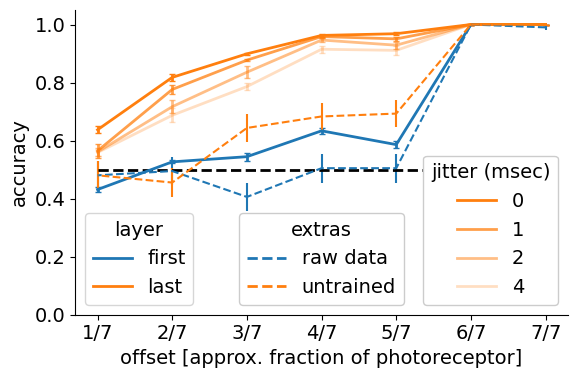

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ranksums
plt.figure(1, figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
ax = plt.gca()
rebuttal_addons = False
stat_addons = True
 #statistical significance is computed for the last layer, between no jitter and the smallest jitter
stats_between = [(len(layers_to_process) - 1,0) , (len(layers_to_process) - 1,2)]
rebuttal_addons = True
labels = ['first', 'last']
colors = ['tab:blue', 'tab:orange']
lj = len(jitters)

# --- plot data (no labels here; we'll build legends manually) ---
for ll, _ in enumerate(layers_to_process):
    is_last_layer = (ll == len(layers_to_process) - 1)

    # only sweep jitters for the last layer; otherwise just the first jitter
    jtr_list = jitters if is_last_layer else [jitters[0]]

    for jj, jitter in enumerate(jtr_list):
        xx = np.array(all_cat_acs_jtr_mdls[jj])
        this_data = np.mean(xx, axis=0)[ll]
        this_std  = np.std(xx, axis=0)[ll] / np.sqrt(xx.shape[0])

        alpha = (lj - jj) / lj if is_last_layer else 1.0

        ax.errorbar(
            vernier_offsets, this_data, this_std,
            color=colors[ll],
            alpha=alpha,
            linewidth=2,
            capsize=2,
        )

#adding statistical significance information
data_for_stats = {}
for ii in range(2):
    jj = stats_between[ii][1]
    ll = stats_between[ii][0]
    data_for_stats[ii] = np.array(all_cat_acs_jtr_mdls[jj])[:,ll,:].T
pvals = by_row_ranksums(data_for_stats[0], data_for_stats[1])
        
#enhanced version for referee        
if rebuttal_addons:
    ax.errorbar(vernier_offsets,raw_acs[0],raw_stde[0], color='tab:blue', linestyle='--')
    ax.errorbar(vernier_offsets,fresh_acs[1], fresh_stde[1],color='tab:orange', linestyle='--')
# chance level line
ax.plot([1, 7], [0.5, 0.5], 'k--', linewidth=2)

ax.set_ylabel('accuracy')
ax.set_xlabel('offset [approx. fraction of photoreceptor]')
ax.set_xticks(ticks=np.arange(1,8),labels=[str(ii)+'/7' for ii in range(1,8)])

ax.set_ylim([0, 1.05])
ax.spines[['right', 'top']].set_visible(False)

# --- Legend 1: Layers (colors) ---
layer_handles = [
    Line2D([0], [0], color=c, lw=2, label=lab)
    for lab, c in zip(labels, colors)
]
# layer_handles.append(Line2D([0], [0], color='k', lw=2, ls='--', label='chance level'))
# layer_handles.append(Line2D([0], [0], color='k', lw=2, ls='--'))

leg1 = ax.legend(handles=layer_handles, title='layer', loc='lower left')
ax.add_artist(leg1)  # keep it when adding the second legend

# --- Legend 2: Jitters (alpha) — only meaningful for last layer ---
jitter_handles = [
    Line2D([0], [0], color=colors[-1], lw=2, alpha=(lj - jj) / lj, label=str(jtr))
    for jj, jtr in enumerate(jitters)
]
leg2 = ax.legend(handles=jitter_handles, title='jitter (msec)', loc='lower right', framealpha=1)
ax.add_artist(leg2) 

if rebuttal_addons:
    rebuttal_handles = [
        Line2D([0], [0], color=c, linestyle='--',lw=2, label=lab)
        for lab, c in zip(['raw data','untrained'], colors)
    ]    
    ax.legend(handles=rebuttal_handles, title='extras', loc='lower center', framealpha=1)

plt.tight_layout()
plt.savefig('figS3panelTop.svg',format='svg')

plt.show()


In [36]:
df = pd.DataFrame({
    "offset_fraction": [f"{ii}/7" for ii in range(7, 0, -1)],
    "offset_numeric": vernier_offsets,
    "raw_accuracy": raw_acs[0],
    "raw_sem": raw_stde[0],
    "fresh_accuracy": fresh_acs[1],
    "fresh_sem": fresh_stde[1],
})
df.to_csv("figS3panelTop.csv", index=False)


In [37]:
df

,offset_fraction,offset_numeric,raw_accuracy,raw_sem,fresh_accuracy,fresh_sem
0,7/7,7,0.990099,0.009852,1.000000,0.000000
1,6/7,6,1.000000,0.000000,1.000000,0.000000
2,5/7,5,0.504950,0.049749,0.693069,0.045893
3,4/7,4,0.504950,0.049749,0.683168,0.046293
4,3/7,3,0.405941,0.048864,0.643564,0.047657
5,2/7,2,0.495050,0.049749,0.455446,0.049554
6,1/7,1,0.480392,0.049469,0.480392,0.049469


In [39]:


from fig_utils import bar_plots_with_significances, add_manual_legend, pvals_by_row, p_to_stars

In [40]:

def build_bar_inputs_from_jitter_layer_tensor(
    all_cat_acs_jtr_mdls,   # list over jitters; each is (n_models, n_layers, n_offsets)
    jitters,                # list of jitter values (must include 0 if you want baseline=0)
    layers_to_process,      # list/iterable of layers; last element is "last layer"
    *,
    baseline_jitter_value=0,
    first_layer_label="first@0",
    last_layer_prefix="last@",
    last_layer_suffix="ms",
    alpha_sweep=True,
    first_color="tab:blue",
    last_color="tab:orange",
):
    """
    Returns:
      bar_vals:   (g, n)
      bar_sem:    (g, n)
      sig_mark:   (g, n) strings
      colorcodes: (n,) each can include alpha as (color, alpha)
      cond_labels:(n,) labels to use for a condition legend
    """
    jitters_list = list(jitters)
    if baseline_jitter_value not in jitters_list:
        raise ValueError(f"baseline_jitter_value={baseline_jitter_value} not found in jitters={jitters_list}")
    j0 = jitters_list.index(baseline_jitter_value)

    n_layers = len(layers_to_process)
    first_ll = 0
    last_ll  = n_layers - 1

    # columns/conditions: first@baseline + last@each jitter
    conds = [("first", j0)] + [("last", jj) for jj in range(len(jitters_list))]
    n = len(conds)

    # infer number of offsets from tensor
    xx0 = np.asarray(all_cat_acs_jtr_mdls[j0])
    n_models, _, n_offsets = xx0.shape
    g = n_offsets

    bar_vals = np.zeros((g, n), float)
    bar_sem  = np.zeros((g, n), float)
    sig_mark = np.full((g, n), "", dtype=object)

    # fill means/sems
    for ci, (tag, jj) in enumerate(conds):
        ll = first_ll if tag == "first" else last_ll
        xx = np.asarray(all_cat_acs_jtr_mdls[jj])  # (n_models, n_layers, n_offsets)

        mean = xx.mean(axis=0)[ll]  # (n_offsets,)
        sem  = xx.std(axis=0, ddof=1)[ll] / np.sqrt(xx.shape[0])

        bar_vals[:, ci] = mean
        bar_sem[:,  ci] = sem
    # compute stars vs baseline for last-layer jitters
    base = np.asarray(all_cat_acs_jtr_mdls[j0])[:, last_ll, :]  # (n_models, n_offsets)
    for ci, (tag, jj) in enumerate(conds):
        if tag != "last" or jj == j0:
            continue
        comp = np.asarray(all_cat_acs_jtr_mdls[jj])[:, last_ll, :]
        pvals = pvals_by_row(base.T, comp.T)
        sig_mark[:, ci] = [p_to_stars(p) for p in pvals]

    # colors per condition (supports alpha)
    n_last = len(jitters_list)
    colorcodes = [(first_color, 1.0)]
    for jj in range(n_last):
        a = (n_last - jj) / n_last if alpha_sweep else 1.0
        colorcodes.append((last_color, a))

    # labels for condition legend (optional)
    cond_labels = [first_layer_label] + [f"{last_layer_prefix}{j}{last_layer_suffix}" for j in jitters_list]

    return bar_vals, bar_sem, sig_mark, colorcodes, cond_labels




In [41]:
def sig_bracket(x1,x2, h=1.0, d=0.025):
    ax = plt.gca()
    uu = ax.plot((x1,x1,x2,x2),(h-d,h,h,h-d), 'k')
    uu[0].set_clip_on(False)


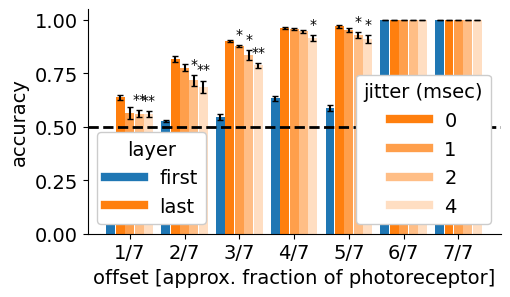

In [42]:
group_x = vernier_offsets  # e.g. [1,2,3,4,5,6,7]
group_labels = [f"{int(v)}/7" for v in group_x]

bar_vals, bar_sem, sig_mark, colorcodes, cond_labels = build_bar_inputs_from_jitter_layer_tensor(
    all_cat_acs_jtr_mdls=all_cat_acs_jtr_mdls,
    jitters=jitters,
    layers_to_process=layers_to_process,
    baseline_jitter_value=0,
)


fig, ax = bar_plots_with_significances(
    bar_vals, sig_mark, colorcodes, group_labels,
    yerr_by_group=bar_sem,
    group_x=group_x,          # <-- restores old left-to-right behavior
    sort_groups="by_x",       # <-- default; ensures 1/6 is leftmost
    chance_line=0.5,
    xlabel="offset [approx. fraction of photoreceptor]",
    ylabel="accuracy",
    ylim=(0, 1.05),
    fontsize=14,
    fontsize_stars=10,
    figsize=(5.2, 3.2),
)

# two legends like before
# legend_layer(ax, labels=["first", "last"], colors=["tab:blue", "tab:orange"], loc="lower left")
# legend_jitter_alpha(ax, jitters=jitters, base_color="tab:orange", loc="lower right")

# Legend 1 (colors)
leg1 = add_manual_legend(
    ax,
    labels=["first", "last"],
    colorcodes=["tab:blue", "tab:orange"],
    title="layer",
    loc="lower left",
    add_artist=True,   # keep when adding the second legend
)

# Legend 2 (alpha sweep on same base color)
jitter_labels = [str(j) for j in jitters]
jitter_colorcodes = [( "tab:orange", (len(jitters)-jj)/len(jitters) ) for jj in range(len(jitters))]
# or: jitter_colorcodes = sweep_color_alpha("tab:orange", len(jitters), start=1.0, end=1.0/len(jitters))

leg2 = add_manual_legend(
    ax,
    labels=jitter_labels,
    colorcodes=jitter_colorcodes,
    title="jitter (msec)",
    loc="lower right",
    add_artist=False,
)
leg2.set_zorder(1000)



plt.show()

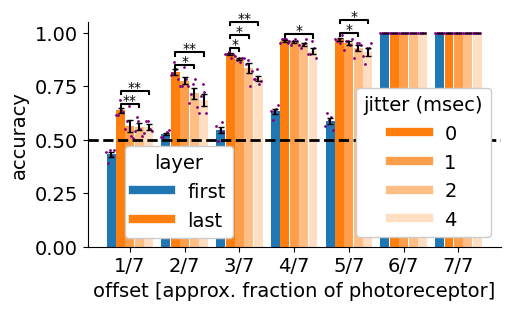

In [44]:
'''
replot using manual significance signs 
'''

group_x = vernier_offsets  # e.g. [1,2,3,4,5,6,7]
group_width=0.86


group_labels = [f"{int(v)}/7" for v in group_x]

bar_vals, bar_sem, sig_mark, colorcodes, cond_labels = build_bar_inputs_from_jitter_layer_tensor(
    all_cat_acs_jtr_mdls=all_cat_acs_jtr_mdls,
    jitters=jitters,
    layers_to_process=layers_to_process,
    baseline_jitter_value=0,
)


empty_sigmark = copy.deepcopy(sig_mark)
empty_sigmark[:,:]=''

fig, ax = bar_plots_with_significances(
    bar_vals, empty_sigmark, colorcodes, group_labels,
    yerr_by_group=bar_sem,
    group_x=group_x,          # <-- restores old left-to-right behavior
    sort_groups="by_x",       # <-- default; ensures 1/6 is leftmost
    chance_line=0.5,
    xlabel="offset [approx. fraction of photoreceptor]",
    ylabel="accuracy",
    ylim=(0, 1.05),
    fontsize=14,
    fontsize_stars=10,
    group_width = group_width,
    figsize=(5.2, 3.2),
)

# two legends like before
# legend_layer(ax, labels=["first", "last"], colors=["tab:blue", "tab:orange"], loc="lower left")
# legend_jitter_alpha(ax, jitters=jitters, base_color="tab:orange", loc="lower right")

# Legend 1 (colors)
leg1 = add_manual_legend(
    ax,
    labels=["first", "last"],
    colorcodes=["tab:blue", "tab:orange"],
    title="layer",
    loc=(0.09,0.04), #"lower left",
    add_artist=True,   # keep when adding the second legend
)

# Legend 2 (alpha sweep on same base color)
jitter_labels = [str(j) for j in jitters]
jitter_colorcodes = [( "tab:orange", (len(jitters)-jj)/len(jitters) ) for jj in range(len(jitters))]
# or: jitter_colorcodes = sweep_color_alpha("tab:orange", len(jitters), start=1.0, end=1.0/len(jitters))

leg2 = add_manual_legend(
    ax,
    labels=jitter_labels,
    colorcodes=jitter_colorcodes,
    title="jitter (msec)",
    loc="lower right",
    add_artist=False,
)
leg2.set_zorder(1000)
# leg2.set_bbox_to_anchor(0.96, 1.0),


ref_id = 1 #second column counting from 0
n_groups = bar_vals.shape[0]
n = bar_vals.shape[1] 
delta_x = group_width/n
ref_x = delta_x*(ref_id+1/2-n/2)
delta_h = 0.06
for ii_, these_sig_marks in enumerate(sig_mark):
    ii = n_groups - 1 - ii_
    h0 = np.max(bar_vals[ii_])
    cnt = 0
    for jj, this_sig_mark in enumerate(these_sig_marks):
        if this_sig_mark !='':
            this_x =  delta_x*(jj+1/2-n/2)
            x1,x2 = (ii+1)+ref_x, (ii+1)+this_x
            h = h0+0.03+delta_h*cnt
            sig_bracket(x1,x2, h=h, d=0.015)
            # plt.text( (x1+x2)/2,h,'p<0.3', horizontalalignment='center',fontsize=10)
            plt.text( (x1+x2)/2,h,this_sig_mark, horizontalalignment='center',fontsize=10)
            cnt += 1

#-----------------------plotting individual points

ptpt_data = np.zeros((2,7,4,5)) #[layers,offsets,jitters,seeds]

for jitter_ix,cat_acs_mdls in all_cat_acs_jtr_mdls.items():
    for seed_ix,cat_acs_mdl in enumerate(cat_acs_mdls):
        for layer_ix, these_accs in enumerate(cat_acs_mdl):
            ptpt_data[layer_ix,:,jitter_ix,seed_ix] = these_accs
relevant_ptpt_data = np.concatenate([ptpt_data[0,:,0:1,:],ptpt_data[1]],axis =1) #[offsets,jitters&layer,seeds]


for offset_idx,data0 in enumerate(relevant_ptpt_data):
    rev_offset_idx = n_groups - offset_idx
    for jit_lay_ix, data1 in enumerate(data0):
        
        # this_x =  rev_offset_idx+delta_x*(jit_lay_ix+1/2-n/2) + delta_x*np.arange(len(data1))/len(data1)
        this_x =  rev_offset_idx+delta_x*(jit_lay_ix-n/2) + delta_x*np.arange(len(data1))/len(data1)
        # plt.plot(this_x*np.ones_like(data1),data1, '.',color='purple', markersize=2)
        plt.plot(this_x,data1, '.',color='purple', markersize=2)



#----------------------
plt.savefig('fig4panelD.svg',format='svg')

plt.show()




In [45]:
from scipy.stats import  ranksums

offsets = [f"{i}/7" for i in range(7, 0, -1)]

conditions = [
    ("first", 0),
    ("last", 0),  # baseline
    ("last", 1),
    ("last", 2),
    ("last", 4),
]

rows = []

for offset_idx, offset in enumerate(offsets):

    # Baseline vector for this offset (across seeds)
    baseline = relevant_ptpt_data[offset_idx, 1, :]  # ("last", 0)

    for cond_idx, (layer, jitter) in enumerate(conditions):

        values = relevant_ptpt_data[offset_idx, cond_idx, :]

        # Wilcoxon ranksums test against baseline
        if cond_idx == 1:
            p_value = np.nan  # baseline compared to itself
        else:
            try:
                _, p_value = ranksums(
                    values,
                    baseline,
                    alternative="two-sided"
                )
            except ValueError:
                # occurs when differences are all zero
                p_value = 1.0

        row = {
            "offset": offset,
            "layer": layer,
            "jitter": jitter,
            "ranksums_p_vs_last_layer_jitter0": p_value,
        }

        row.update({
            f"seed_{seed + 1}": values[seed]
            for seed in range(values.shape[0])
        })

        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("fig4panelD.csv", index=False)

In [ ]:
df